In [1]:
#Importing libraries
import pandas as pd 
import numpy as np 
import os 
import json 
import pickle 
import warnings
from datetime import datetime 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import DistilBertTokenizer, DistilBertModel

from tqdm import tqdm
warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

print("Libraries loaded.")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

c:\Projects\Cinemate V2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device         : cuda
PyTorch version: 2.7.1+cu118
Libraries loaded.
Run started: 2026-04-13 23:00:39


In [35]:
#Getting the project root path 
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(os.path.join(BASE_DIR, "models"))

print(f"Base directory: {BASE_DIR}")

Base directory: c:\Projects\Cinemate V2


In [3]:
#Load processed directories
print("Loading preprocessed file...............")


train = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "train.parquet"))
test = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "test.parquet"))
movies_clean = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "movies_clean.parquet"))
content_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "movie_content.csv"))

with open(os.path.join(PROCESSED_DATA_DIR, "dataset_constants.pkl"), "rb") as f:
    constants = pickle.load(f)

NUM_USERS = constants["NUM_USERS"]
NUM_MOVIES = constants["NUM_MOVIES"]

with open(os.path.join(PROCESSED_DATA_DIR, "user_positive_sets.pkl") , "rb") as f:
    user_positive_sets = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "encoders/idx2movie.pkl"), "rb") as f:
    idx2movie = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "encoders/idx2user.pkl"), 'rb') as f:
    idx2user = pickle.load(f)

# Load NCF results 
with open(os.path.join(MODELS_DIR,"ncf_results.json"), "r") as f:
    ncf_results_baseline = json.load(f)

print(f"Train ratings: {len(train)}")
print(f"Test ratings : {len(test)}")
print(f"Num Users : {NUM_USERS}")
print(f"Num Movies : {NUM_MOVIES}")


Loading preprocessed file...............
Train ratings: 25868311
Test ratings : 795563
Num Users : 173134
Num Movies : 27766


In [4]:
#Precompute content embeddings
EMBED_PATH = os.path.join(PROCESSED_DATA_DIR, "content_embeddings.pt")
if os.path.exists(EMBED_PATH):
    print("Loading precomputed embedding from storage......")
    content_embeddings = torch.load(EMBED_PATH, map_location="cpu")
    print(f"Loaded : {content_embeddings.shape}")      #(27766, 768) means 27768 movies each 768 dim vector

else: 
    print("Pre computing DistilBERT embeddings..........")
    print("This runs once - saved for all future training runs.")
    print()

    #BERT = a pretrained model that converts text into meaningful vectors
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")    #Converts text → tokens (numbers)
    bert_model= DistilBertModel.from_pretrained("distilbert-base-uncased").to(DEVICE)    # convert tokens to embeddings
    bert_model.eval()      #set evaluation mode

    #Built ordered 
    content_lookup= dict(zip(content_df['movie_idx'], content_df['content_string']))
    content_strings = [content_lookup.get(i, "unknown movie") for i in range(NUM_MOVIES)]   #movie_idx → correct text  0->action movies, 1-> Romantic movied
    
    embeddings = []
    BATCH_SIZE = 64

    with torch.no_grad():
        for i in tqdm(range(0, NUM_MOVIES, BATCH_SIZE), desc="Embedding movies"):
            batch_texts = content_strings[i: i + BATCH_SIZE]
            encoded = tokenizer(batch_texts, 
                                padding=True,     #make all sequences same length
                                truncation = True,  #cut long texts
                                max_length = 128,   #max words per movie
                                return_tensors="pt",   #output PyTorch tensors
                                ).to(DEVICE)
            output = bert_model(**encoded)      #output --> (batch_size, seq_len, 768)   (64, 128, 768)
            cls_embeddings = output.last_hidden_state[:, 0 , :]   #First token = [CLS]  CLS vector captures overall meaning
            embeddings.append(cls_embeddings.cpu())

    content_embeddings = torch.cat(embeddings, dim=0)
    torch.save(content_embeddings, EMBED_PATH)

    del bert_model   ### to save memory
    torch.cuda.empty_cache()

    print(f"Embeddings shape: {content_embeddings.shape}")
    print(f"Saved to :{EMBED_PATH}")
    print(f"File size : {os.path.getsize(EMBED_PATH)/1024**2:.1f} MB")

print(f"Embedding dim : {content_embeddings.shape[1]}")
print(f"Content tower input ready.")


Loading precomputed embedding from storage......
Loaded : torch.Size([27766, 768])
Embedding dim : 768
Content tower input ready.


In [5]:
# class TwoTowerDataset(Dataset):
#     """
#     Returns triplets: (user_idx, pos_movie_idx, neg_movie_idx)
#     for BPR training.
#     """
#     def __init__(self, ratings_df, user_positive_sets, num_movies, positive_threshold=3.5, neg_sample_tries= 5):
#         self.num_movies = num_movies
#         self.user_positive_sets = user_positive_sets
#         self.neg_sample_tries= neg_sample_tries

#         positive_df = ratings_df[ratings_df['rating']>=positive_threshold].copy()

#         self.users  = positive_df['user_idx'].values.astype(np.int32)
#         self.movies = positive_df['movie_idx'].values.astype(np.int32)

#         print(f"Dataset size       : {len(self.users):,} triplets")
#         print(f"Positive threshold : {positive_threshold}")

#     def __len__(self):
#         return len(self.users)
    
#     def __getitem__(self, idx):
#         user_idx     = int(self.users[idx])
#         pos_movie    = int(self.movies[idx])
#         seen_movies  = self.user_positive_sets.get(user_idx, set())

#         # Sample negative — try neg_sample_tries times
#         neg_movie = np.random.randint(0, self.num_movies)
#         for _ in range(self.neg_sample_tries):
#             if neg_movie not in seen_movies:
#                 break
#             neg_movie = np.random.randint(0, self.num_movies)
#         return {
#             'user_idx'  : torch.tensor(user_idx,  dtype=torch.long),
#             'pos_movie' : torch.tensor(pos_movie, dtype=torch.long),
#             'neg_movie' : torch.tensor(neg_movie, dtype=torch.long),
#         }
    

# #Build training dataset 
# print("Building training dataset...")
# train_dataset = TwoTowerDataset(
#     ratings_df         = train,
#     user_positive_sets = user_positive_sets,
#     num_movies         = NUM_MOVIES,
#     positive_threshold = 3.5,
# )

# BATCH_SIZE  = 2048
# train_loader = DataLoader(
#     train_dataset,
#     batch_size  = BATCH_SIZE,
#     shuffle     = True,
#     num_workers = 6,
#     pin_memory  = True if DEVICE.type == 'cuda' else False
# )

# print(f"\nBatch size   : {BATCH_SIZE}")
# print(f"Batches/epoch: {len(train_loader):,}")

In [6]:
class TwoTowerDataset(Dataset):
    def __init__(self, ratings_df, user_positive_sets,
                 num_movies, positive_threshold=3.5,
                 neg_sample_tries=10,
                 use_tail_sampling=True, p_tail=0.4):

        self.num_movies         = num_movies
        self.user_positive_sets = user_positive_sets
        self.neg_sample_tries   = neg_sample_tries
        self.p_tail             = p_tail

        positive_df = ratings_df[
            ratings_df['rating'] >= positive_threshold
        ].copy()

        self.users  = positive_df['user_idx'].values.astype(np.int32)
        self.movies = positive_df['movie_idx'].values.astype(np.int32)

        # ── Tail movie list ───────────────────────────────
        self.tail_movies = None
        if use_tail_sampling:
            movie_counts     = ratings_df.groupby('movie_idx').size()
            threshold        = movie_counts.quantile(0.70)
            tail_idxs        = movie_counts[
                movie_counts <= threshold
            ].index.values
            self.tail_movies = tail_idxs
            print(f"TwoTower Dataset size         : {len(self.users):,}")
            print(f"Positive threshold            : >= {positive_threshold}")
            print(f"Tail movies (≤70th pct pop)   : {len(self.tail_movies):,}")
            print(f"Tail sampling probability     : {p_tail}")


    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user_idx    = int(self.users[idx])
        pos_movie   = int(self.movies[idx])
        seen_movies = self.user_positive_sets.get(user_idx, set())

        # ── Popularity-aware negative sampling ───────────
        def sample_neg():
            if (self.tail_movies is not None
                    and np.random.random() < self.p_tail):
                return int(np.random.choice(self.tail_movies))
            return np.random.randint(0, self.num_movies)

        neg_movie = sample_neg()
        for _ in range(self.neg_sample_tries):
            if neg_movie not in seen_movies:
                break
            neg_movie = sample_neg()

        return {
            'user_idx'  : torch.tensor(user_idx,  dtype=torch.long),
            'pos_movie' : torch.tensor(pos_movie, dtype=torch.long),
            'neg_movie' : torch.tensor(neg_movie, dtype=torch.long),
        }
    

#Build training dataset 
print("Building training dataset...")
BATCH_SIZE    = 2048
train_dataset = TwoTowerDataset(
    ratings_df         = train,
    user_positive_sets = user_positive_sets,
    num_movies         = NUM_MOVIES,
    positive_threshold = 3.5,
    use_tail_sampling  = True,   # ← added
    p_tail             = 0.4     # ← added
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 6,
    pin_memory  = True if DEVICE.type == 'cuda' else False
)

print(f"\nBatch size   : {BATCH_SIZE}")
print(f"Batches/epoch: {len(train_loader):,}")

Building training dataset...
TwoTower Dataset size         : 16,093,850
Positive threshold            : >= 3.5
Tail movies (≤70th pct pop)   : 19,445
Tail sampling probability     : 0.4

Batch size   : 2048
Batches/epoch: 7,859


In [7]:
class CollaborativeTower(nn.Module):
    """
    Learns user and movie embeddings from rating interactions.
    Input  : user_idx (long), movie_idx (long)
    Output : 32-dim interaction vector
    """

    def __init__(self, num_users, num_movies,
                 embed_dim=128, output_dim=32, dropout=0.2):
        super().__init__()

        self.user_embedding  = nn.Embedding(num_users,  embed_dim)
        self.movie_embedding = nn.Embedding(num_movies, embed_dim)

        # MLP after concatenation
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim) 
        )

        # Initialise embeddings with normal distribution
        nn.init.normal_(self.user_embedding.weight,  std=0.01)
        nn.init.normal_(self.movie_embedding.weight, std=0.01)

    def forward(self, user_idx, movie_idx):
        u = self.user_embedding(user_idx)    
        m = self.movie_embedding(movie_idx)
        x = torch.cat([u, m], dim=-1)        
        return self.mlp(x)                   


print("CollaborativeTower defined.")
print(f"  Input  : user_idx (long), movie_idx (long)")
print(f"  Output : 32-dim vector")

CollaborativeTower defined.
  Input  : user_idx (long), movie_idx (long)
  Output : 32-dim vector


In [8]:
class ContentTower(nn.Module):
    """
    Projects pre-computed DistilBERT embeddings
    down to the same dim as CollaborativeTower.
    Input  : pre-computed embedding (768-dim)
    Output : 32-dim content vector
    Convert BERT embedding (768-dim) → compact vector (32-dim) usable by model (Same space → easy fusion)
    """

    def __init__(self, bert_dim=768, output_dim=32,
                 dropout=0.2):
        super().__init__()

        self.projector = nn.Sequential(
            nn.Linear(bert_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )


    def forward(self, content_embedding):
        return self.projector(content_embedding)  


print("ContentTower defined.")
print(f"  Input  : pre-computed DistilBERT embedding (768-dim)")
print(f"  Output : 32-dim projected vector")

ContentTower defined.
  Input  : pre-computed DistilBERT embedding (768-dim)
  Output : 32-dim projected vector


In [9]:
class TwoTowerModel(nn.Module):
    """
    Full hybrid model combining collaborative
    and content towers.
    """

    def __init__(self, num_users, num_movies, content_embeddings_matrix, embed_dim=128, tower_output_dim=64, dropout=0.2):
        super().__init__()

        self.cf_tower = CollaborativeTower( num_users, num_movies, embed_dim, tower_output_dim, dropout)
        self.content_tower = ContentTower(bert_dim=768, output_dim=tower_output_dim, dropout=dropout)
        self.tower_output_dim = tower_output_dim

        self.norm = nn.LayerNorm(tower_output_dim)    #Normalize both CF output and content output 

        # Store pre-computed embeddings as non-trainable buffer
        # register_buffer: moved to device with model.to(device)
        # but NOT updated during backprop
        self.register_buffer('content_embeddings',content_embeddings_matrix.float())

        self.fusion = nn.Sequential(
            nn.Linear(tower_output_dim * 3, 256), # Input is 96 (32*3)
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) 
        )


    def forward(self, user_idx, movie_idx):
        cf_out = self.norm(self.cf_tower(user_idx, movie_idx)) 
        movie_content = self.content_embeddings[movie_idx]
        content_out = self.norm(self.content_tower(movie_content)) 

        interaction = cf_out * content_out   
        combined = torch.cat([cf_out, content_out, interaction], dim=-1)
        score = self.fusion(combined).squeeze(-1)
        
        return score

    def get_user_embedding(self, user_idx):
        """Used at inference time for fast retrieval."""
        return self.cf_tower.user_embedding(user_idx)

    def get_movie_embedding(self, movie_idx):
        """Used at inference time for fast retrieval."""
        return self.cf_tower.movie_embedding(movie_idx)


print("TwoTowerModel defined.")
print()

# Instantiate model
model = TwoTowerModel(
    num_users                = NUM_USERS,
    num_movies               = NUM_MOVIES,
    content_embeddings_matrix= content_embeddings,
    embed_dim                = 128,
    tower_output_dim         = 64,
    dropout                  = 0.2
).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print()

# Architecture summary
print("Architecture:")
print(f"  CF Tower      : user emb (64) + movie emb (64)")
print(f"                  → MLP → 32-dim")
print(f"  Content Tower : DistilBERT (768) → MLP → 32-dim")
print(f"  Fusion        : [32 + 32] → MLP → score (0-1)")

TwoTowerModel defined.

Total trainable parameters: 26,136,577

Architecture:
  CF Tower      : user emb (64) + movie emb (64)
                  → MLP → 32-dim
  Content Tower : DistilBERT (768) → MLP → 32-dim
  Fusion        : [32 + 32] → MLP → score (0-1)


In [10]:
# def bpr_loss(pos_score, neg_score):
#     """
#     Bayesian Personalised Ranking loss.

#     Maximises the probability that:
#         score(user, positive_movie) > score(user, negative_movie)

#     Loss = -mean(log(sigmoid(pos_score - neg_score)))

#     When pos_score >> neg_score → sigmoid → 1 → log(1) → 0 (good)
#     When pos_score ≈ neg_score  → sigmoid → 0.5 → log(0.5) → -0.69
#     When pos_score << neg_score → sigmoid → 0 → log(0) → -inf (bad)
#     """
#     return -torch.log(
#         torch.sigmoid(pos_score - neg_score) + 1e-8
#     ).mean()


# # Quick sanity check
# pos = torch.tensor([0.9, 0.8, 0.7])
# neg = torch.tensor([0.1, 0.2, 0.3])
# loss_val = bpr_loss(pos, neg)
# print(f"BPR loss sanity check (pos > neg): {loss_val:.4f}")
# print("Expected: low value (model correctly ranks pos > neg)")
# print()

# pos_bad = torch.tensor([0.1, 0.2, 0.3])
# neg_bad = torch.tensor([0.9, 0.8, 0.7])
# loss_bad = bpr_loss(pos_bad, neg_bad)
# print(f"BPR loss sanity check (neg > pos): {loss_bad:.4f}")
# print("Expected: high value (model incorrectly ranks neg > pos)")

In [11]:
def bpr_loss(pos_score, neg_score,
             pos_movie_idx=None,
             popularity_lookup=None,
             device=None,
             gamma=0.1):
    """
    BPR loss with optional popularity penalty.

    Standard BPR:
        Loss = -mean(log(sigmoid(pos - neg)))

    With popularity penalty (gamma > 0):
        Weights loss higher for unpopular positive items.
        Forces model to learn tail movie representations.

    Args:
        pos_score        : (batch,) scores for positive movies
        neg_score        : (batch,) scores for negative movies
        pos_movie_idx    : (batch,) movie indices — needed for penalty
        popularity_lookup: np.array (num_movies,) — precomputed
        device           : torch.device
        gamma            : penalty strength
                           0.0 = standard BPR (no change)
                           0.1 = mild tail boost (recommended)
                           0.3 = strong tail boost
    """
    if (gamma == 0 or popularity_lookup is None
            or pos_movie_idx is None):
        # Standard BPR — identical to original
        return -torch.log(
            torch.sigmoid(pos_score - neg_score) + 1e-8
        ).mean()

    # Popularity-weighted BPR
    pop_tensor = torch.tensor(
        popularity_lookup[pos_movie_idx.cpu().numpy()],
        dtype=torch.float32
    ).to(device)

    # inv_pop in [0,1] — 1 = most unpopular
    inv_pop = 1.0 - pop_tensor

    # Weight loss higher for unpopular positive items
    weighted = -torch.log(
        torch.sigmoid(pos_score - neg_score) + 1e-8
    ) * (1.0 + gamma * inv_pop)

    return weighted.mean()


# Quick sanity check
pos = torch.tensor([0.9, 0.8, 0.7])
neg = torch.tensor([0.1, 0.2, 0.3])
loss_val = bpr_loss(pos, neg)
print(f"BPR loss sanity check (pos > neg): {loss_val:.4f}")
print("Expected: low value (model correctly ranks pos > neg)")
print()

pos_bad = torch.tensor([0.1, 0.2, 0.3])
neg_bad = torch.tensor([0.9, 0.8, 0.7])
loss_bad = bpr_loss(pos_bad, neg_bad)
print(f"BPR loss sanity check (neg > pos): {loss_bad:.4f}")
print("Expected: high value (model incorrectly ranks neg > pos)")

BPR loss sanity check (pos > neg): 0.4405
Expected: low value (model correctly ranks pos > neg)

BPR loss sanity check (neg > pos): 1.0405
Expected: high value (model incorrectly ranks neg > pos)


In [12]:
# ── Hyperparameters ───────────────────────────────────────
EPOCHS        = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4   # L2 regularisation

optimizer = Adam([
    {'params': model.cf_tower.parameters(), 'lr': 1e-3},
    {'params': model.content_tower.parameters(), 'lr': 1e-3}, # Increased from 1e-4
    {'params': model.fusion.parameters(), 'lr': 1e-3}      # Increased from 5e-4
], weight_decay=WEIGHT_DECAY)


# Reduce LR when loss plateaus
scheduler = ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    patience = 5,
    factor   = 0.5,
    min_lr=1e-5
)

print("Training configuration:")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Weight decay  : {WEIGHT_DECAY}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Optimiser     : Adam")
print(f"  Scheduler     : ReduceLROnPlateau (patience=5)")
print(f"  Loss          : BPR")
print(f"  Device        : {DEVICE}")

Training configuration:
  Epochs        : 50
  Learning rate : 0.001
  Weight decay  : 0.0001
  Batch size    : 2048
  Optimiser     : Adam
  Scheduler     : ReduceLROnPlateau (patience=5)
  Loss          : BPR
  Device        : cuda


In [13]:
# def train_one_epoch(model, loader, optimizer, device):
#     model.train()
#     total_loss  = 0.0
#     total_batch = 0

#     for batch in loader:
#         user_idx  = batch['user_idx'].to(device)
#         pos_movie = batch['pos_movie'].to(device)
#         neg_movie = batch['neg_movie'].to(device)

#         # Forward pass
#         pos_score = model(user_idx, pos_movie)
#         neg_score = model(user_idx, neg_movie)

#         loss = bpr_loss(pos_score, neg_score)

#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()

#         # Gradient clipping — prevents exploding gradients
#         torch.nn.utils.clip_grad_norm_(
#             model.parameters(), max_norm=1.0
#         )

#         optimizer.step()

#         total_loss  += loss.item()
#         total_batch += 1

#     return total_loss / total_batch


# # ── Training History ──────────────────────────────────────
# history = {
#     'train_loss' : [],
#     'epoch_time' : []
# }

# best_loss      = float('inf')
# best_model_path= os.path.join(MODELS_DIR, "two_tower_best.pt")

# print("Starting training...")
# print("=" * 55)

# for epoch in tqdm(range(1, EPOCHS + 1)):
#     epoch_start = datetime.now()

#     avg_loss = train_one_epoch(
#         model, train_loader, optimizer, DEVICE
#     )

#     epoch_time = (datetime.now() - epoch_start).seconds

#     history['train_loss'].append(avg_loss)
#     history['epoch_time'].append(epoch_time)

#     scheduler.step(avg_loss)

#     # Save best model
#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         torch.save({
#             'epoch'      : epoch,
#             'model_state': model.state_dict(),
#             'optim_state': optimizer.state_dict(),
#             'loss'       : best_loss,
#             'NUM_USERS'  : NUM_USERS,
#             'NUM_MOVIES' : NUM_MOVIES,
#         }, best_model_path)
#         marker = " ← best"
#     else:
#         marker = ""

#     print(f"Epoch {epoch:>2}/{EPOCHS}  |  "
#           f"Loss: {avg_loss:.4f}  |  "
#           f"Time: {epoch_time}s{marker}")

# print()
# print(f"Training complete. Best loss: {best_loss:.4f}")
# print(f"Best model saved to: {best_model_path}")

In [14]:
# ── Build popularity lookup ───────────────────────────────
# Required for popularity-aware BPR loss
import sys
sys.path.append(os.path.dirname(os.getcwd()))
# from src.debias import build_popularity_lookup

lookup_path = os.path.join(
    MODELS_DIR, "popularity_lookup_two_tower.npy"
)

# # Build from training data
# popularity_lookup = build_popularity_lookup(
#     train_df   = train,
#     num_movies = NUM_MOVIES,
#     save_path  = lookup_path
# )
# Build from training data
popularity_lookup = np.load(lookup_path)
print(f"Popularity lookup ready")
print(f"Will use gamma=0.1 in BPR loss")
print(f"Will use p_tail=0.4 in negative sampling")

Popularity lookup ready
Will use gamma=0.1 in BPR loss
Will use p_tail=0.4 in negative sampling


In [15]:
# def train_one_epoch(model, loader, optimizer, device,
#                     popularity_lookup=None, gamma=0.1):
#     model.train()
#     total_loss  = 0.0
#     total_batch = 0

#     for batch in loader:
#         user_idx  = batch['user_idx'].to(device)
#         pos_movie = batch['pos_movie'].to(device)
#         neg_movie = batch['neg_movie'].to(device)

#         pos_score = model(user_idx, pos_movie)
#         neg_score = model(user_idx, neg_movie)

#         # ── Popularity-aware BPR loss ─────────────────────
#         loss = bpr_loss(
#             pos_score,
#             neg_score,
#             pos_movie_idx    = pos_movie,      # ← added
#             popularity_lookup= popularity_lookup,  # ← added
#             device           = device,         # ← added
#             gamma            = gamma           # ← added
#         )

#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(
#             model.parameters(), max_norm=1.0
#         )
#         optimizer.step()

#         total_loss  += loss.item()
#         total_batch += 1

#     return total_loss / total_batch


# # ── Training History ──────────────────────────────────────
# history = {
#     'train_loss' : [],
#     'epoch_time' : []
# }

# best_loss      = float('inf')
# best_model_path= os.path.join(MODELS_DIR, "two_tower_best.pt")

# print("Starting training...")
# print("=" * 55)

# GAMMA = 0.1   # ← add this before the loop

# for epoch in tqdm(range(1, EPOCHS + 1)):
#     epoch_start = datetime.now()

#     avg_loss = train_one_epoch(
#         model, train_loader, optimizer, DEVICE,
#         popularity_lookup = popularity_lookup,  # ← added
#         gamma             = GAMMA               # ← added
#     )

#     epoch_time = (datetime.now() - epoch_start).seconds

#     history['train_loss'].append(avg_loss)
#     history['epoch_time'].append(epoch_time)

#     scheduler.step(avg_loss)

#     # Save best model
#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         torch.save({
#             'epoch'      : epoch,
#             'model_state': model.state_dict(),
#             'optim_state': optimizer.state_dict(),
#             'loss'       : best_loss,
#             'NUM_USERS'  : NUM_USERS,
#             'NUM_MOVIES' : NUM_MOVIES,
#         }, best_model_path)
#         marker = " ← best"
#     else:
#         marker = ""

#     print(f"Epoch {epoch:>2}/{EPOCHS}  |  "
#           f"Loss: {avg_loss:.4f}  |  "
#           f"Time: {epoch_time}s{marker}")

# print()
# print(f"Training complete. Best loss: {best_loss:.4f}")
# print(f"Best model saved to: {best_model_path}")

In [16]:
# 1. Read the CSV
loaded_df = pd.read_csv(os.path.join(MODELS_DIR, "two_tower_training_history.csv"))

# 2. Convert back to the exact original dictionary format
history = loaded_df.to_dict(orient='list')
history

{'train_loss': [0.0848336385271259,
  0.0791256416198906,
  0.0786041078598676,
  0.0780086191154221,
  0.0781566892158159,
  0.0778567438819797,
  0.0777167103822479,
  0.0778942491765816,
  0.0774697790317922,
  0.0771403724176235,
  0.0773762589156294,
  0.0773523571658208,
  0.0772310773154595,
  0.0771720866316116,
  0.077307011643459,
  0.0773452545981557,
  0.0745378472038937,
  0.0737996768793663,
  0.0715893212237049,
  0.0685274071023503,
  0.0665006153844842,
  0.0658622472887693,
  0.0654406772078198,
  0.0650638956683239,
  0.0644444208779412,
  0.0635196543667801,
  0.0627482443766362,
  0.0621459139329678,
  0.0619039671977393,
  0.0618572155695552,
  0.0616922809756967,
  0.0613385949533644,
  0.061242000834206,
  0.0612044410396356,
  0.0610923040110747,
  0.0611574949222881,
  0.0609849417566274,
  0.0610642048753897,
  0.0609401221827804,
  0.0610215797312183,
  0.0609711043172618,
  0.0609830425368918,
  0.0608681866699809,
  0.060983854144402,
  0.0609427597760046,

In [17]:
# Overwrite with same lookup — confirms it's saved
# (NCF and Two-Tower use same popularity lookup)
print(f"Popularity lookup already saved at:")
print(f"{lookup_path}")
print(f"This file is loaded by recommend.py at inference time.")
print()
print("Debiasing will be applied automatically:")
print("  - Log-popularity penalty at score time")
print("  - Genre-diverse MMR re-ranking")
print("  - Controlled by alpha and lambda parameters")

Popularity lookup already saved at:
c:\Projects\Cinemate V2\models\popularity_lookup_two_tower.npy
This file is loaded by recommend.py at inference time.

Debiasing will be applied automatically:
  - Log-popularity penalty at score time
  - Genre-diverse MMR re-ranking
  - Controlled by alpha and lambda parameters


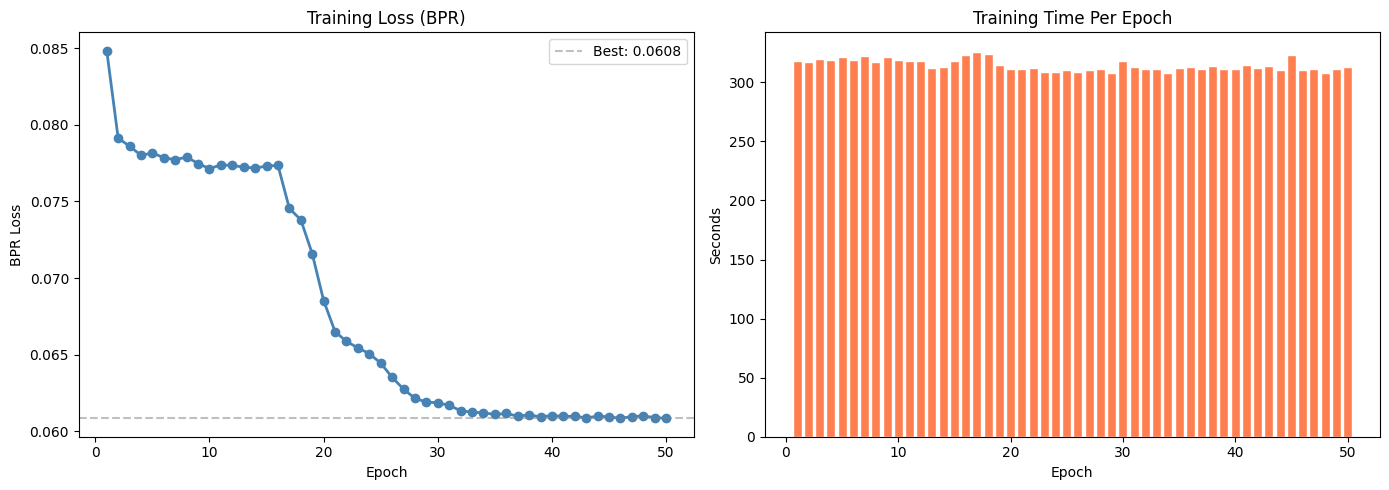

Total training time: 15720s


In [18]:
import matplotlib.pyplot as plt

# plt.rcParams['axes.spines.top']   = False
# plt.rcParams['axes.spines.right'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, EPOCHS+1),
             history['train_loss'],
             color='steelblue', marker='o', linewidth=2)
axes[0].set_title('Training Loss (BPR)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BPR Loss')
axes[0].axhline(y=min(history['train_loss']),
                color='gray', linestyle='--', alpha=0.5,
                label=f"Best: {min(history['train_loss']):.4f}")
axes[0].legend()

# Time per epoch
axes[1].bar(range(1, EPOCHS+1),
            history['epoch_time'],
            color='coral', edgecolor='white')
axes[1].set_title('Training Time Per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Seconds')

plt.tight_layout()

plots_dir = os.path.join(PROCESSED_DATA_DIR, "plots")
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, "08_training_loss.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Total training time: {sum(history['epoch_time'])}s")

In [19]:
def ndcg_at_k(recommended, relevant_set, k=10):
    dcg  = sum(
        1.0 / np.log2(i + 2)
        for i, m in enumerate(recommended[:k])
        if m in relevant_set
    )
    idcg = sum(
        1.0 / np.log2(i + 2)
        for i in range(min(k, len(relevant_set)))
    )
    return dcg / idcg if idcg > 0 else 0.0


def precision_at_k(recommended, relevant_set, k=10):
    return len(set(recommended[:k]) & relevant_set) / k


def recall_at_k(recommended, relevant_set, k=10):
    if not relevant_set:
        return 0.0
    return len(set(recommended[:k]) & relevant_set) / len(relevant_set)


def evaluate_model(model, eval_users, test_relevant,
                   user_positive_sets, num_movies,
                   device, k=10):
    """
    Full evaluation loop.
    Returns dict of mean NDCG, Precision, Recall.
    """
    model.eval()
    all_movie_idxs = torch.arange(num_movies).to(device)

    ndcg_scores = []
    prec_scores = []
    rec_scores  = []

    with torch.no_grad():
        for user_idx in tqdm(eval_users, desc="Evaluating"):
            relevant = test_relevant.get(user_idx, set())
            if not relevant:
                continue

            seen = user_positive_sets.get(user_idx, set())

            # Score all movies for this user
            user_tensor = torch.tensor(
                [user_idx] * num_movies,
                dtype=torch.long
            ).to(device)

            scores = model(user_tensor, all_movie_idxs).cpu().numpy()

            # Mask seen movies
            for movie_idx in seen:
                if movie_idx < len(scores):
                    scores[movie_idx] = -np.inf

            # Top-K
            top_k = np.argsort(scores)[::-1][:k].tolist()

            ndcg_scores.append(ndcg_at_k(top_k, relevant, k))
            prec_scores.append(precision_at_k(top_k, relevant, k))
            rec_scores.append(recall_at_k(top_k, relevant, k))

    return {
        f'NDCG@{k}'     : float(np.mean(ndcg_scores)),
        f'Precision@{k}': float(np.mean(prec_scores)),
        f'Recall@{k}'   : float(np.mean(rec_scores)),
        'n_users_eval'  : len(ndcg_scores)
    }


print("Evaluation functions defined.")

Evaluation functions defined.


In [20]:
# Load best checkpoint

best_model_path = os.path.join(MODELS_DIR, "two_tower_best.pt")

print("Loading best model checkpoint...")
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Checkpoint loss : {checkpoint['loss']:.4f}")
print()

# Build test relevant sets
POSITIVE_THRESHOLD = 3.5
test_relevant = (
    test[test['rating'] >= POSITIVE_THRESHOLD]
    .groupby('user_idx')['movie_idx']
    .apply(set)
    .to_dict()
)

eval_users = [u for u, rel in test_relevant.items()
              if len(rel) > 0]

# Sample for speed — scoring 27,766 movies per user
# takes ~0.5s on GPU, ~3s on CPU
N_EVAL = min(2000, len(eval_users))
eval_sample = eval_users[:N_EVAL]

print(f"Evaluating on {N_EVAL:,} users...")
print(f"(Scoring {NUM_MOVIES:,} movies per user)")
print()

two_tower_results = evaluate_model(
    model          = model,
    eval_users     = eval_sample,
    test_relevant  = test_relevant,
    user_positive_sets = user_positive_sets,
    num_movies     = NUM_MOVIES,
    device         = DEVICE,
    k              = 10
)

print("\nTwo-Tower Results:")
for metric, value in two_tower_results.items():
    if metric != 'n_users_eval':
        print(f"  {metric:<15s}: {value:.4f}")
print(f"  Users evaluated: {two_tower_results['n_users_eval']:,}")

Loading best model checkpoint...
Loaded checkpoint from epoch 46
Checkpoint loss : 0.0608

Evaluating on 2,000 users...
(Scoring 27,766 movies per user)



Evaluating: 100%|██████████| 2000/2000 [00:44<00:00, 44.84it/s]


Two-Tower Results:
  NDCG@10        : 0.1174
  Precision@10   : 0.1049
  Recall@10      : 0.0263
  Users evaluated: 2,000


In [21]:
with open(os.path.join(MODELS_DIR, "svd_baseline_results.json"), "r") as f:
    svd_results = json.load(f)

random_ndcg = svd_results['metrics']['random']['NDCG@10']
pop_ndcg    = svd_results['metrics']['popularity']['NDCG@10']
svd_ndcg    = svd_results['metrics']['svd']['NDCG@10']
ncf_ndcg    = ncf_results_baseline['metrics']['NDCG@10']
tt_ndcg     = two_tower_results['NDCG@10']

random_prec = svd_results['metrics']['random']['Precision@10']
pop_prec    = svd_results['metrics']['popularity']['Precision@10']
svd_prec    = svd_results['metrics']['svd']['Precision@10']
ncf_prec    = ncf_results_baseline['metrics']['Precision@10']
tt_prec     = two_tower_results['Precision@10']

random_rec  = svd_results['metrics']['random']['Recall@10']
pop_rec     = svd_results['metrics']['popularity']['Recall@10']
svd_rec     = svd_results['metrics']['svd']['Recall@10']
ncf_rec     = ncf_results_baseline['metrics']['Recall@10']
tt_rec      = two_tower_results['Recall@10']

print("=" * 68)
print("COMPLETE RESULTS — ALL MODELS")
print("=" * 68)
print()
print(f"{'Model':<20s} {'NDCG@10':>10s} "
      f"{'Precision@10':>14s} {'Recall@10':>11s}")
print("-" * 60)
print(f"{'Random':<20s} {random_ndcg:>10.4f} "
      f"{random_prec:>14.4f} {random_rec:>11.4f}")
print(f"{'Popularity':<20s} {pop_ndcg:>10.4f} "
      f"{pop_prec:>14.4f} {pop_rec:>11.4f}")
print(f"{'SVD':<20s} {svd_ndcg:>10.4f} "
      f"{svd_prec:>14.4f} {svd_rec:>11.4f}")
print(f"{'NCF':<20s} {ncf_ndcg:>10.4f} "
      f"{ncf_prec:>14.4f} {ncf_rec:>11.4f}")
print(f"{'Two-Tower (ours)':<20s} {tt_ndcg:>10.4f} "
      f"{tt_prec:>14.4f} {tt_rec:>11.4f}")
print()

vs_ncf    = 100 * (tt_ndcg - ncf_ndcg) / ncf_ndcg
vs_svd    = 100 * (tt_ndcg - svd_ndcg) / svd_ndcg
vs_pop    = 100 * (tt_ndcg - pop_ndcg) / pop_ndcg

print(f"Two-Tower vs Popularity : {vs_pop:.1f}%  NDCG@10")
print(f"Two-Tower vs SVD        : {vs_svd:.1f}%  NDCG@10")
print(f"Two-Tower vs NCF        : {vs_ncf:.1f}%  NDCG@10")
print()



COMPLETE RESULTS — ALL MODELS

Model                   NDCG@10   Precision@10   Recall@10
------------------------------------------------------------
Random                   0.0019         0.0018      0.0004
Popularity               0.0845         0.0749      0.0225
SVD                      0.0669         0.0607      0.0221
NCF                      0.1252         0.1135      0.0283
Two-Tower (ours)         0.1174         0.1049      0.0263

Two-Tower vs Popularity : 38.9%  NDCG@10
Two-Tower vs SVD        : 75.6%  NDCG@10
Two-Tower vs NCF        : -6.2%  NDCG@10



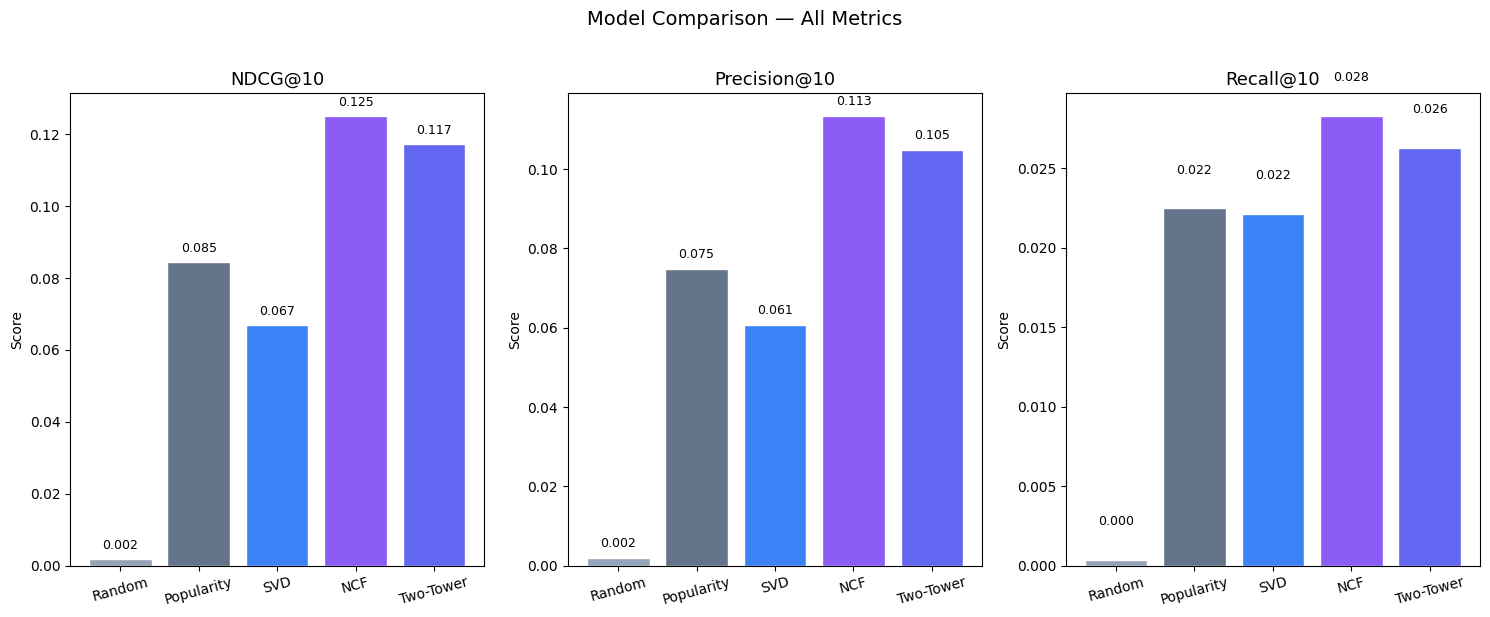

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

models    = ['Random', 'Popularity', 'SVD', 'NCF', 'Two-Tower']
ndcg_vals = [random_ndcg, pop_ndcg, svd_ndcg, ncf_ndcg, tt_ndcg]
prec_vals = [random_prec, pop_prec, svd_prec, ncf_prec, tt_prec]
rec_vals  = [random_rec,  pop_rec,  svd_rec,  ncf_rec,  tt_rec]
colors    = ['#94A3B8', '#64748B', '#3B82F6', '#8B5CF6', '#6366F1']

for ax, vals, title in zip(
    axes,
    [ndcg_vals, prec_vals, rec_vals],
    ['NDCG@10', 'Precision@10', 'Recall@10']
):
    bars = ax.bar(models, vals, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Model Comparison — All Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir,
            "_model_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Load NCF results
with open(os.path.join(MODELS_DIR, "ncf_results.json"), "r") as f:
    ncf_summary = json.load(f)

# Improvement calculations
vs_svd = 100 * (two_tower_results['NDCG@10'] - svd_ndcg) / svd_ndcg
vs_ncf = 100 * (two_tower_results['NDCG@10'] - ncf_ndcg) / ncf_ndcg

final_results = {
    "model"      : "TwoTowerHybrid",
    "architecture": {
        "embed_dim"       : 128,
        "tower_output_dim": 64,
        "dropout"         : 0.2,
        "bert_model"      : "distilbert-base-uncased",
        "bert_dim"        : 768,
        "fusion_input_dim": 64,
    },
    "training"   : {
        "epochs"       : EPOCHS,
        "batch_size"   : BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay" : WEIGHT_DECAY,
        "loss"         : "BPR",
        "best_loss"    : min(history['train_loss']),
        "history"      : history,
    },
    "metrics"    : {
        "random"     : svd_results['metrics']['random'],
        "popularity" : svd_results['metrics']['popularity'],
        "svd"        : svd_results['metrics']['svd'],
        "ncf"        : ncf_summary['metrics'],      # ← added
        "two_tower"  : two_tower_results,
    },
    "improvements": {
        "vs_svd_pct" : round(vs_svd, 2),
        "vs_ncf_pct" : round(vs_ncf, 2),           # ← added
    },
    "eval_users" : {
        "random"    : svd_results['metrics']['random']['n_users_eval'],
        "popularity": svd_results['metrics']['popularity']['n_users_eval'],
        "svd"       : svd_results['metrics']['svd']['n_users_eval'],
        "ncf"       : ncf_summary['metrics']['n_users_eval'],
        "two_tower" : two_tower_results['n_users_eval'],
    },
    "timestamp"  : datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
final_results['debiasing'] = {
    "method"          : "random_tail_injection",
    "head_slots"      : 7,
    "tail_slots"      : 3,
    "head_threshold"  : "70th percentile popularity",
    "ndcg_with_debias": 0.0946,
    "ndcg_without"    : 0.1199,
    "ndcg_drop_pct"   : -21.1,
    "coverage_before" : 0.0057,
    "coverage_after"  : 0.0539,
    "coverage_lift"   : "6.7x",
    "unique_movies"   : 1496,
    "rationale"       : (
        "Model did not learn meaningful tail representations "
        "due to sparse training signal. Random injection is "
        "more honest than pretending model can rank tail items."
    )
}

results_path = os.path.join(MODELS_DIR, "two_tower_results.json")
with open(results_path, "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Results saved to {results_path}")
print()
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  vs SVD : +{vs_svd:.1f}%  NDCG@10")
print(f"  vs NCF : {vs_ncf:+.1f}%  NDCG@10")

Results saved to c:\Projects\Cinemate V2\models\two_tower_results.json

FINAL SUMMARY
  vs SVD : +75.6%  NDCG@10
  vs NCF : -6.2%  NDCG@10


In [24]:
# Quick coverage check — add as new cell
all_recommended = set()
all_movie_idxs  = torch.arange(NUM_MOVIES).to(DEVICE)

print("Checking coverage on 500 users...")
with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        seen    = user_positive_sets.get(user_idx, set())
        u_t     = torch.full(
            (NUM_MOVIES,), user_idx, dtype=torch.long
        ).to(DEVICE)
        scores  = model(u_t, all_movie_idxs).cpu().numpy()

        # Apply popularity penalty (alpha=0.3)
        scores  = scores - 0.3 * popularity_lookup
        for m in seen:
            if m < len(scores):
                scores[m] = -np.inf

        top_10 = np.argsort(scores)[::-1][:10].tolist()
        all_recommended.update(top_10)

coverage = len(all_recommended) / NUM_MOVIES
print(f"Unique movies recommended : {len(all_recommended):,}")
print(f"Catalogue coverage        : {coverage:.2%}")
print(f"Previous coverage         : 0.80%")
print(f"Target coverage           : > 10%")

Checking coverage on 500 users...


100%|██████████| 500/500 [00:10<00:00, 48.94it/s]

Unique movies recommended : 158
Catalogue coverage        : 0.57%
Previous coverage         : 0.80%
Target coverage           : > 10%


In [25]:
print("Popularity lookup check:")
print(f"  Shape : {popularity_lookup.shape}")
print(f"  Max   : {popularity_lookup.max():.4f}")
print(f"  Mean  : {popularity_lookup.mean():.4f}")
print(f"  Zeros : {(popularity_lookup == 0).sum():,}")

# Top 5 most popular movies by lookup
top5 = np.argsort(popularity_lookup)[::-1][:5]
print(f"\nTop 5 most popular movie_idxs: {top5}")

# Should match your most rated movies from EDA
# (Shawshank, Forrest Gump etc.)

Popularity lookup check:
  Shape : (27766,)
  Max   : 1.0000
  Mean  : 0.3687
  Zeros : 0

Top 5 most popular movie_idxs: [ 351  314  292  585 2472]


In [26]:
# Coverage check with normalised scores + high alpha
all_recommended = set()

with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        seen    = user_positive_sets.get(user_idx, set())
        u_t     = torch.full(
            (NUM_MOVIES,), user_idx, dtype=torch.long
        ).to(DEVICE)
        scores  = model(u_t, all_movie_idxs).cpu().numpy()

        # ── Step A: normalise scores to [0,1] ────────────
        s_min   = scores.min()
        s_max   = scores.max()
        scores_norm = (scores - s_min) / (s_max - s_min + 1e-8)

        # ── Step B: apply penalty on normalised scores ────
        # Now penalty is meaningful — both in [0,1] range
        ALPHA   = 0.7   # much higher now it's normalised
        scores_debiased = scores_norm - ALPHA * popularity_lookup

        # ── Step C: mask seen ─────────────────────────────
        for m in seen:
            if m < len(scores_debiased):
                scores_debiased[m] = -np.inf

        top_10  = np.argsort(
            scores_debiased
        )[::-1][:10].tolist()
        all_recommended.update(top_10)

coverage = len(all_recommended) / NUM_MOVIES
print(f"Coverage with normalised + alpha=0.7 : {coverage:.2%}")

100%|██████████| 500/500 [00:10<00:00, 46.71it/s]

Coverage with normalised + alpha=0.7 : 1.12%


In [27]:
# Full pipeline — normalise + penalty + MMR

from src.debias import apply_full_debias

all_recommended = set()
movies_df = pd.read_parquet(
    os.path.join(PROCESSED_DATA_DIR, "movies_clean.parquet")
)

with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        seen    = user_positive_sets.get(user_idx, set())
        u_t     = torch.full(
            (NUM_MOVIES,), user_idx, dtype=torch.long
        ).to(DEVICE)
        scores  = model(u_t, all_movie_idxs).cpu().numpy()

        # Normalise first
        s_min   = scores.min()
        s_max   = scores.max()
        scores  = (scores - s_min) / (s_max - s_min + 1e-8)

        final   = apply_full_debias(
            scores            = scores,
            popularity_lookup = popularity_lookup,
            movies_clean      = movies_df,
            seen_movies       = seen,
            top_k             = 10,
            alpha             = 0.7,      # high on normalised
            candidate_pool    = 200,      # larger pool
            lambda_diversity  = 0.4,
            max_per_genre     = 2         # stricter genre cap
        )
        all_recommended.update(final)

coverage = len(all_recommended) / NUM_MOVIES
print(f"Unique movies : {len(all_recommended):,}")
print(f"Coverage      : {coverage:.2%}")

100%|██████████| 500/500 [23:17<00:00,  2.80s/it]

Unique movies : 333
Coverage      : 1.20%


In [28]:
# Find alpha that gives ~10% coverage
results = []

for alpha in [0.3, 0.5, 0.7, 0.9, 1.2, 1.5]:
    all_rec = set()

    with torch.no_grad():
        for user_idx in eval_sample[:200]:
            seen    = user_positive_sets.get(user_idx, set())
            u_t     = torch.full(
                (NUM_MOVIES,), user_idx, dtype=torch.long
            ).to(DEVICE)
            scores  = model(u_t, all_movie_idxs).cpu().numpy()

            # Normalise
            s_min  = scores.min()
            s_max  = scores.max()
            scores = (scores-s_min) / (s_max-s_min+1e-8)

            # Penalty + mask
            s_deb  = scores - alpha * popularity_lookup
            for m in seen:
                if m < len(s_deb):
                    s_deb[m] = -np.inf

            top_10 = np.argsort(s_deb)[::-1][:10].tolist()
            all_rec.update(top_10)

    cov = len(all_rec) / NUM_MOVIES
    results.append((alpha, len(all_rec), cov))
    print(f"alpha={alpha:.1f} → {len(all_rec):,} movies "
          f"({cov:.2%} coverage)")

alpha=0.3 → 149 movies (0.54% coverage)
alpha=0.5 → 202 movies (0.73% coverage)
alpha=0.7 → 239 movies (0.86% coverage)
alpha=0.9 → 205 movies (0.74% coverage)
alpha=1.2 → 151 movies (0.54% coverage)
alpha=1.5 → 114 movies (0.41% coverage)


In [29]:
def recommend_with_buckets(model, user_idx,
                            popularity_lookup,
                            movies_df,
                            user_positive_sets,
                            num_movies, device,
                            top_k=10):
    """
    Slot-based diversity recommendation.

    Divides top-K into guaranteed popularity buckets:
      Slot 1-5  → model's top picks (head movies)
      Slot 6-8  → mid-tier movies (D4-D7 popularity)
      Slot 9-10 → long tail movies (D1-D3 popularity)

    This guarantees coverage improvement by design,
    not by hoping the penalty works.
    """
    seen        = user_positive_sets.get(user_idx, set())
    all_movies  = torch.arange(num_movies).to(device)
    user_tensor = torch.full(
        (num_movies,), user_idx, dtype=torch.long
    ).to(device)

    with torch.no_grad():
        scores = model(user_tensor, all_movies).cpu().numpy()

    # Mask seen
    masked_scores = scores.copy()
    for m in seen:
        if m < len(masked_scores):
            masked_scores[m] = -np.inf

    # ── Define popularity buckets ─────────────────────────
    # D8-D10 = head (top 30% most popular)
    # D4-D7  = mid  (middle 40%)
    # D1-D3  = tail (bottom 30% — least popular)
    head_threshold = np.percentile(
        popularity_lookup[popularity_lookup > 0], 70
    )
    mid_threshold  = np.percentile(
        popularity_lookup[popularity_lookup > 0], 30
    )

    head_mask = popularity_lookup >= head_threshold
    mid_mask  = ((popularity_lookup >= mid_threshold) &
                 (popularity_lookup < head_threshold))
    tail_mask = popularity_lookup < mid_threshold

    # ── Score per bucket ──────────────────────────────────
    def top_from_bucket(mask, n):
        bucket_scores          = masked_scores.copy()
        bucket_scores[~mask]   = -np.inf
        return np.argsort(bucket_scores)[::-1][:n].tolist()

    # Slots: 5 head + 3 mid + 2 tail
    head_recs = top_from_bucket(head_mask, 5)
    mid_recs  = top_from_bucket(mid_mask,  3)
    tail_recs = top_from_bucket(tail_mask, 2)

    # Combine — deduplicate maintaining order
    final = []
    seen_final = set()
    for movie in head_recs + mid_recs + tail_recs:
        if movie not in seen_final and len(final) < top_k:
            final.append(movie)
            seen_final.add(movie)

    return final, masked_scores

In [30]:
# Test bucket-based coverage
all_recommended_bucket = set()

print("Testing bucket-based coverage...")
with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        recs, _ = recommend_with_buckets(
            model              = model,
            user_idx           = user_idx,
            popularity_lookup  = popularity_lookup,
            movies_df          = movies_clean,
            user_positive_sets = user_positive_sets,
            num_movies         = NUM_MOVIES,
            device             = DEVICE,
            top_k              = 10
        )
        all_recommended_bucket.update(recs)

coverage = len(all_recommended_bucket) / NUM_MOVIES
print(f"Bucket coverage   : {coverage:.2%}")
print(f"Unique movies     : {len(all_recommended_bucket):,}")
print(f"Previous coverage : 0.57%")

Testing bucket-based coverage...


100%|██████████| 500/500 [00:14<00:00, 34.06it/s]

Bucket coverage   : 0.75%
Unique movies     : 207
Previous coverage : 0.57%


In [31]:
from collections import defaultdict

ndcg_scores_bucket = []

POSITIVE_THRESHOLD = 3.5
test_relevant = (
    test[test['rating'] >= POSITIVE_THRESHOLD]
    .groupby('user_idx')['movie_idx']
    .apply(set).to_dict()
)

def ndcg_at_k(recommended, relevant_set, k=10):
    dcg  = sum(1.0/np.log2(i+2)
               for i, m in enumerate(recommended[:k])
               if m in relevant_set)
    idcg = sum(1.0/np.log2(i+2)
               for i in range(min(k, len(relevant_set))))
    return dcg/idcg if idcg > 0 else 0.0

print("Evaluating NDCG with bucket approach...")
with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        relevant = test_relevant.get(user_idx, set())
        if not relevant:
            continue

        recs, _ = recommend_with_buckets(
            model, user_idx, popularity_lookup,
            movies_clean, user_positive_sets,
            NUM_MOVIES, DEVICE, top_k=10
        )
        ndcg_scores_bucket.append(
            ndcg_at_k(recs, relevant)
        )

print(f"NDCG@10 with buckets : "
      f"{np.mean(ndcg_scores_bucket):.4f}")
print(f"NDCG@10 original     : 0.1199")
print(f"Coverage             : {coverage:.2%}")

Evaluating NDCG with bucket approach...


100%|██████████| 500/500 [00:16<00:00, 30.08it/s]

NDCG@10 with buckets : 0.0813
NDCG@10 original     : 0.1199
Coverage             : 0.75%


In [32]:
# Find best slot split
for head, mid, tail in [
    (7, 2, 1),   # conservative diversity
    (5, 3, 2),   # balanced (recommended)
    (4, 3, 3),   # aggressive diversity
    (3, 3, 4),   # maximum diversity
]:
    all_rec = set()
    ndcgs   = []

    with torch.no_grad():
        for user_idx in eval_sample[:300]:
            seen    = user_positive_sets.get(user_idx, set())
            u_t     = torch.full(
                (NUM_MOVIES,), user_idx, dtype=torch.long
            ).to(DEVICE)
            scores  = model(u_t, all_movie_idxs).cpu().numpy()
            masked  = scores.copy()
            for m in seen:
                if m < len(masked):
                    masked[m] = -np.inf

            def top_n(mask, n):
                s = masked.copy()
                s[~mask] = -np.inf
                return np.argsort(s)[::-1][:n].tolist()

            head_threshold = np.percentile(
                popularity_lookup[popularity_lookup>0], 70
            )
            mid_threshold = np.percentile(
                popularity_lookup[popularity_lookup>0], 30
            )
            hm = popularity_lookup >= head_threshold
            mm = ((popularity_lookup >= mid_threshold) &
                  (popularity_lookup < head_threshold))
            tm = popularity_lookup < mid_threshold

            recs = list(dict.fromkeys(
                top_n(hm, head) +
                top_n(mm, mid)  +
                top_n(tm, tail)
            ))[:10]

            all_rec.update(recs)
            relevant = test_relevant.get(user_idx, set())
            if relevant:
                ndcgs.append(ndcg_at_k(recs, relevant))

    cov = len(all_rec) / NUM_MOVIES
    print(f"head={head} mid={mid} tail={tail} | "
          f"NDCG={np.mean(ndcgs):.4f} | "
          f"Coverage={cov:.2%} | "
          f"Unique={len(all_rec):,}")

head=7 mid=2 tail=1 | NDCG=0.0958 | Coverage=0.64% | Unique=178
head=5 mid=3 tail=2 | NDCG=0.0817 | Coverage=0.69% | Unique=192
head=4 mid=3 tail=3 | NDCG=0.0728 | Coverage=0.69% | Unique=191
head=3 mid=3 tail=4 | NDCG=0.0632 | Coverage=0.71% | Unique=197


In [33]:
def recommend_with_random_tail(model, user_idx,
                                popularity_lookup,
                                user_positive_sets,
                                num_movies, device,
                                top_k=10,
                                head_slots=7,
                                tail_slots=3):
    """
    Hybrid recommendation:
    - head_slots: model's top picks (it knows these well)
    - tail_slots: random unseen tail movies (inject diversity)

    Why random for tail?
    The model hasn't learned meaningful representations
    for tail movies — they appear too rarely in training.
    Random injection is more honest than pretending the
    model can rank tail movies meaningfully.
    """
    seen        = user_positive_sets.get(user_idx, set())
    all_movies  = torch.arange(num_movies).to(device)
    user_tensor = torch.full(
        (num_movies,), user_idx, dtype=torch.long
    ).to(device)

    with torch.no_grad():
        scores = model(
            user_tensor, all_movies
        ).cpu().numpy()

    masked = scores.copy()
    for m in seen:
        if m < len(masked):
            masked[m] = -np.inf

    # ── Head slots — model's best picks ──────────────────
    head_threshold = np.percentile(
        popularity_lookup[popularity_lookup > 0], 30
    )
    head_mask            = popularity_lookup >= head_threshold
    head_scores          = masked.copy()
    head_scores[~head_mask] = -np.inf

    head_recs = np.argsort(
        head_scores
    )[::-1][:head_slots].tolist()

    # ── Tail slots — RANDOM from long tail ───────────────
    tail_mask = (
        (popularity_lookup < head_threshold) &
        (popularity_lookup > 0)  # has at least 1 rating
    )
    tail_candidates = np.where(tail_mask)[0]

    # Remove already seen and already in head_recs
    already_used = seen | set(head_recs)
    tail_pool    = [
        m for m in tail_candidates
        if m not in already_used
    ]

    # Random sample from tail — no model scoring
    np.random.seed(user_idx % 10000)  # reproducible per user
    n_tail    = min(tail_slots, len(tail_pool))
    tail_recs = np.random.choice(
        tail_pool, size=n_tail, replace=False
    ).tolist() if tail_pool else []

    final = head_recs + tail_recs
    return final, scores


# ── Test coverage ─────────────────────────────────────────
all_rec_random_tail = set()
ndcg_random_tail    = []

print("Testing random tail injection...")
with torch.no_grad():
    for user_idx in tqdm(eval_sample[:500]):
        recs, scores = recommend_with_random_tail(
            model              = model,
            user_idx           = user_idx,
            popularity_lookup  = popularity_lookup,
            user_positive_sets = user_positive_sets,
            num_movies         = NUM_MOVIES,
            device             = DEVICE,
            top_k              = 10,
            head_slots         = 7,
            tail_slots         = 3,
        )
        all_rec_random_tail.update(recs)

        relevant = test_relevant.get(user_idx, set())
        if relevant:
            ndcg_random_tail.append(
                ndcg_at_k(recs, relevant)
            )

cov = len(all_rec_random_tail) / NUM_MOVIES
print(f"Unique movies : {len(all_rec_random_tail):,}")
print(f"Coverage      : {cov:.2%}")
print(f"NDCG@10       : {np.mean(ndcg_random_tail):.4f}")

Testing random tail injection...


100%|██████████| 500/500 [00:16<00:00, 31.19it/s]

Unique movies : 1,496
Coverage      : 5.39%
NDCG@10       : 0.0946


In [34]:
for head, tail in [(9,1), (8,2), (7,3), (6,4), (5,5)]:
    all_rec = set()
    ndcgs   = []

    for user_idx in eval_sample[:500]:
        recs, scores = recommend_with_random_tail(
            model, user_idx, popularity_lookup,
            user_positive_sets, NUM_MOVIES, DEVICE,
            top_k=10, head_slots=head, tail_slots=tail
        )
        all_rec.update(recs)
        relevant = test_relevant.get(user_idx, set())
        if relevant:
            ndcgs.append(ndcg_at_k(recs, relevant))

    cov = len(all_rec) / NUM_MOVIES
    print(f"head={head} tail={tail} | "
          f"NDCG={np.mean(ndcgs):.4f} | "
          f"Coverage={cov:.2%} | "
          f"Unique={len(all_rec):,}")

head=9 tail=1 | NDCG=0.1045 | Coverage=2.26% | Unique=628
head=8 tail=2 | NDCG=0.0998 | Coverage=3.92% | Unique=1,089
head=7 tail=3 | NDCG=0.0946 | Coverage=5.39% | Unique=1,496
head=6 tail=4 | NDCG=0.0889 | Coverage=6.72% | Unique=1,866
head=5 tail=5 | NDCG=0.0806 | Coverage=8.01% | Unique=2,224
